#Workflow
1) Data Preprocessing (Shared for Both Models)

In [ ]:
from datasets import load_dataset
dataset = load_dataset("fancyzhx/yelp_polarity")


### Inspecting the Dataset Structure and First Rows

In [ ]:
import pandas as pd

# Convert the 'train' split of the dataset to a pandas DataFrame
train_df = pd.DataFrame(dataset['train'])

# Display the first 5 rows of the DataFrame
display(train_df.head())

,text,label
0,"Unfortunately, the frustration of being Dr. Go...",0
1,Been going to Dr. Goldberg for over 10 years. ...,1
2,I don't know what Dr. Goldberg was like before...,0
3,I'm writing this review to give you a heads up...,0
4,All the food is great here. But the best thing...,1


In [ ]:
# Display concise summary of the DataFrame, including data types and non-null values
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560000 entries, 0 to 559999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    560000 non-null  object
 1   label   560000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 8.5+ MB


In [ ]:
# Generate descriptive statistics of the DataFrame
display(train_df.describe())

,label
count,560000.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.5
75%,1.0
max,1.0


In [ ]:
# Display the count of each unique label
print("Sum of each label:")
display(train_df['label'].value_counts())

Sum of each label:


,count
label,
0,280000
1,280000


### Clean Text Data (Lowercase for `train_df`)

In [ ]:
import re

def clean_text_for_df(text):
    # Convert text to lowercase
    text = text.lower()
    return text

# Apply the cleaning function to the 'text' column of train_df
train_df['text'] = train_df['text'].apply(clean_text_for_df)

# Display a cleaned example
print(f"Cleaned text example: {train_df['text'][4]}")

Cleaned text example: all the food is great here. but the best thing they have is their wings. their wings are simply fantastic!!  the \""wet cajun\"" are by the best & most popular.  i also like the seasoned salt wings.  wing night is monday & wednesday night, $0.75 whole wings!\n\nthe dining area is nice. very family friendly! the bar is very nice is well.  this place is truly a yinzer's dream!!  \""pittsburgh dad\"" would love this place n'at!!


In [ ]:
pip install emoji

In [ ]:
import emoji
import numpy as np

def count_emojis_in_text(text):
    return emoji.emoji_count(text)

# Using pandas.Series.apply, which is highly optimized for performance
# This method effectively applies the function in a 'vectorized' manner over the Series.
train_df['emoji_count'] = train_df['text'].apply(count_emojis_in_text)

# Count how many texts contain at least one emoji
rows_with_emojis = train_df[train_df['emoji_count'] > 0]

print(f"Number of rows containing emojis: {len(rows_with_emojis)}")

# Display some examples of texts with emojis, if any
if not rows_with_emojis.empty:
    print("\nExamples of texts with emojis:")
    display(rows_with_emojis[['text', 'emoji_count']].head())
else:
    print("No rows with emojis found.")

Number of rows containing emojis: 0
No rows with emojis found.


#Checking for punctuation marks effects : ("?","!")

In [ ]:
# Count '!' and '?' marks using vectorized string operations
train_df['exclamation_count'] = train_df['text'].str.count('!')
train_df['question_count'] = train_df['text'].str.count('\?') # Escape '?' to count it literally

# Filter texts that have either '!' or '?'
texts_with_marks = train_df[(train_df['exclamation_count'] > 0) | (train_df['question_count'] > 0)]

print(f"Number of texts containing '!' or '?': {len(texts_with_marks)}")

# Display examples of these texts, their mark counts, and labels
if not texts_with_marks.empty:
    print("\nExamples of texts with '!' or '?':")
    display(texts_with_marks[['text', 'exclamation_count', 'question_count', 'label']].head())
else:
    print("No texts found containing '!' or '?'.")

<>:3: SyntaxWarning: invalid escape sequence '\?'
<>:3: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_628/2754392827.py:3: SyntaxWarning: invalid escape sequence '\?'
  train_df['question_count'] = train_df['text'].str.count('\?') # Escape '?' to count it literally


Number of texts containing '!' or '?': 99011

Examples of texts with '!' or '?':


,text,exclamation_count,question_count,label
0,unfortunately the frustration of being dr gold...,0,2,0
12,after a morning of thrift store hunting a frie...,0,3,1
17,i got new tires from them and within two weeks...,0,3,0
21,i will start by saying we have a nice new deck...,0,6,0
24,two meals on the recommendation of a friend wh...,0,2,0


In [ ]:
exclamation_counts_by_label = texts_with_marks.groupby('label')['exclamation_count'].sum()
question_counts_by_label = texts_with_marks.groupby('label')['question_count'].sum()

print("Total exclamation marks by label:")
display(exclamation_counts_by_label)

print("\nTotal question marks by label:")
display(question_counts_by_label)

Total exclamation marks by label:


,exclamation_count
label,
0,340614
1,449670



Total question marks by label:


,question_count
label,
0,146801
1,51846


The statistics shows that the differences of **"!"** label has not big , so till now no affects (but we could check if the marks come sequentially or separates , for more assurance) , otherwise **"?"** shows a big differences .

In [ ]:
import re

# Check if the text contains a sequence of two or more exclamation marks (returns 1 if found, 0 otherwise)
train_df['has_repeated_exclamation'] = train_df['text'].apply(lambda x: 1 if re.search(r'!!+', x) else 0)

# Check if the text contains a sequence of two or more question marks (returns 1 if found, 0 otherwise)
train_df['has_repeated_question'] = train_df['text'].apply(lambda x: 1 if re.search(r'\?\?+', x) else 0)

In [ ]:
# Filter texts that have either repeated '!' or repeated '?'
texts_with_repeated_marks = train_df[(train_df['has_repeated_exclamation'] == 1) | (train_df['has_repeated_question'] == 1)]

print(f"Number of texts containing repeated '!' or '?': {len(texts_with_repeated_marks)}")

# Display examples with the binary indicators
if not texts_with_repeated_marks.empty:
    print("\nExamples of texts with repeated marks (1 = Yes, 0 = No):")
    display(texts_with_repeated_marks[['text', 'has_repeated_exclamation', 'has_repeated_question', 'label']].head())
else:
    print("No texts found.")

Number of texts containing repeated '!' or '?': 73822

Examples of texts with repeated marks (1 = Yes, 0 = No):


,text,has_repeated_exclamation,has_repeated_question,label
4,all the food is great here. but the best thing...,1,0,1
40,"okay, so hopefully you haven't been enjoying h...",1,0,0
44,by far the worst most unprofessional dentist i...,1,0,0
56,if you like being greeted in the morning by a ...,1,0,0
62,great little gem! the food was fantastic was v...,1,0,1


In [ ]:
# Group by label to see how many texts in each class contain repeated marks
repeated_excl_dist = texts_with_repeated_marks.groupby('label')['has_repeated_exclamation'].sum()
repeated_ques_dist = texts_with_repeated_marks.groupby('label')['has_repeated_question'].sum()

print("Number of texts with repeated '!' by label:")
display(repeated_excl_dist)

print("\nNumber of texts with repeated '?' by label:")
display(repeated_ques_dist)

Number of texts with repeated '!' by label:


,has_repeated_exclamation
label,
0,31686
1,33525



Number of texts with repeated '?' by label:


,has_repeated_question
label,
0,10685
1,2664


#No big changes on statistics for exclamation mark , so will remove the "!" and keep the "?"

In [ ]:
train_df.head()

,text,label,emoji_count,exclamation_count,question_count,repeated_exclamation_count,repeated_question_count,has_repeated_exclamation,has_repeated_question
0,"unfortunately, the frustration of being dr. go...",0,0,0,2,0,0,0,0
1,been going to dr. goldberg for over 10 years. ...,1,0,0,0,0,0,0,0
2,i don't know what dr. goldberg was like before...,0,0,1,0,0,0,0,0
3,i'm writing this review to give you a heads up...,0,0,1,0,0,0,0,0
4,all the food is great here. but the best thing...,1,0,8,0,3,0,1,0


#Remove the punctuation marks except the "?"

In [ ]:
import string
import re

# Create a string of punctuation to remove, excluding '?'
punctuation_to_remove = string.punctuation.replace('?', '')
# Escape the punctuation for use in a regex character class
regex_pattern = f"[{re.escape(punctuation_to_remove)}]"

def remove_punctuation_except_question(text):
    # Remove the punctuation defined in the pattern
    clean_text = re.sub(regex_pattern, '', text)
    return clean_text

# Apply the function to the text column
train_df['text'] = train_df['text'].apply(remove_punctuation_except_question)

# Display the first few rows to verify the changes
print("Data cleaned: Punctuation removed (except '?')")
display(train_df[['text']].head())

Data cleaned: Punctuation removed (except '?')


,text
0,unfortunately the frustration of being dr gold...
1,been going to dr goldberg for over 10 years i ...
2,i dont know what dr goldberg was like before ...
3,im writing this review to give you a heads up ...
4,all the food is great here but the best thing ...


#Look at any rating inside texts

In [ ]:
import re

# Define word-based numbers
number_words = ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']

# Combined pattern: (digit OR word) followed by optional space and 'star(s)'
# Example matches: '5 stars', '2star', 'five stars', 'tenstar'
combined_star_pattern = r'\b(\d|' + '|'.join(number_words) + r')\s?stars?\b'

# Filter the dataframe for any mention of these star ratings
all_star_mentions = train_df[train_df['text'].str.contains(combined_star_pattern, case=False, regex=True)]

print(f"Total texts mentioning star ratings (numeric or word-based): {len(all_star_mentions)}")

# Display the results
if not all_star_mentions.empty:
    display(all_star_mentions[['text', 'label']].head())
else:
    print("No matching patterns found.")

/tmp/ipykernel_628/781596571.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  all_star_mentions = train_df[train_df['text'].str.contains(combined_star_pattern, case=False, regex=True)]


Total texts mentioning star ratings (numeric or word-based): 41404


,text,label
0,unfortunately the frustration of being dr gold...,0
21,i will start by saying we have a nice new deck...,0
35,barbs country junction gets a 5 star rating fo...,1
39,if i could give this place less than one star ...,0
114,this place teeters between a 2 and a 3 star re...,0


#Check the labels vs rating

#Transfer the words inside texts to valued rating column for rating
Taking the less rating in case mention 2 or more differnt to **reduce the FP**

In [ ]:
import re

# Mapping for word-based numbers to integers
rating_map = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10
}

def extract_binary_rating(text):
    # Find all matches for the rating pattern
    matches = re.findall(combined_star_pattern, text, re.IGNORECASE)
    if matches:
        found_ratings = []
        for match in matches:
            rating_str = match.lower()
            # Convert word or digit to integer
            val = int(rating_str) if rating_str.isdigit() else rating_map.get(rating_str, 0)
            found_ratings.append(val)

        # Take the minimum rating found if there are multiple mentions
        min_rating = min(found_ratings)

        # Return 0 if the minimum rating is 2 or less, 1 if greater than 2
        return 0 if min_rating <= 2 else 1
    return None

# Apply the updated function
train_df['star_rating_binary'] = train_df['text'].apply(extract_binary_rating)

# Display examples where ratings were found
print("Updated 'star_rating_binary' using the lowest mentioned rating:")
display(train_df[train_df['star_rating_binary'].notnull()][['text', 'star_rating_binary', 'label']].head())

Updated 'star_rating_binary' using the lowest mentioned rating:


,text,star_rating_binary,label
0,unfortunately the frustration of being dr gold...,0.0,0
21,i will start by saying we have a nice new deck...,0.0,0
35,barbs country junction gets a 5 star rating fo...,1.0,1
39,if i could give this place less than one star ...,0.0,0
114,this place teeters between a 2 and a 3 star re...,1.0,0


#Count the ratings vs their label to see the distribution

In [ ]:
# Calculate cross-tabulation of extracted binary ratings vs actual labels
rating_label_counts = train_df[train_df['star_rating_binary'].notnull()].groupby(['star_rating_binary', 'label']).size().unstack(fill_value=0)

# Rename indices and columns for clarity
rating_label_counts.index = ['Extracted Rating <= 2 (0)', 'Extracted Rating > 2 (1)']
rating_label_counts.columns = ['Actual Label 0 (Neg)', 'Actual Label 1 (Pos)']

print("Count of star_rating_binary vs actual label:")
display(rating_label_counts)

Count of star_rating_binary vs actual label:


,Actual Label 0 (Neg),Actual Label 1 (Pos)
Extracted Rating <= 2 (0),18772,1617
Extracted Rating > 2 (1),5867,15148


#We are fail in cases like 114 sample , so we should increase the confident by another feature like the **length of text.**

Text length statistics by label:


,mean,median,std,min,max
label,,,,,
0,790.645543,582.0,707.991171,0,4935
1,608.169404,444.0,558.958538,0,4990


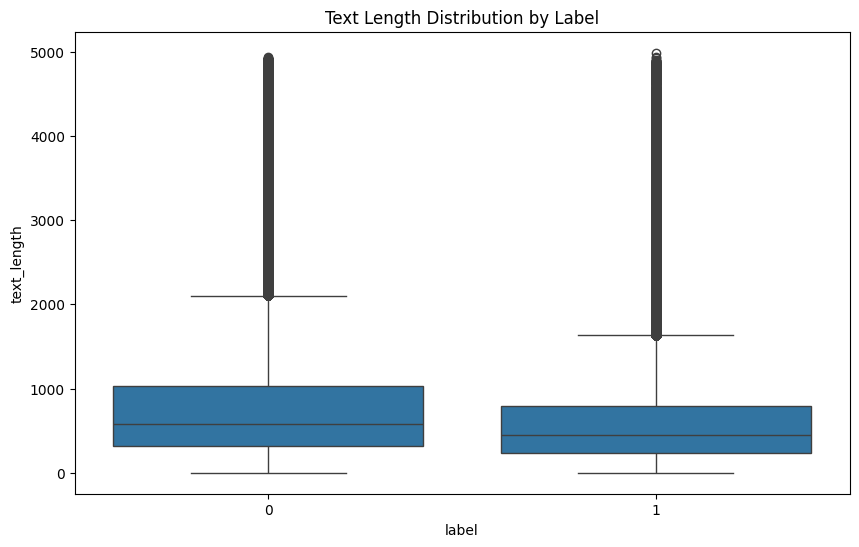

In [ ]:
# Calculate the length of each review
train_df['text_length'] = train_df['text'].str.len()

# Group by label to see length statistics
length_stats = train_df.groupby('label')['text_length'].agg(['mean', 'median', 'std', 'min', 'max'])

print("Text length statistics by label:")
display(length_stats)

# Optional: display distribution summary
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='text_length', data=train_df)
plt.title('Text Length Distribution by Label')
plt.show()

#Remove the empty /Whitespace reviews

In [ ]:
import pandas as pd

# Count rows before removal
initial_count = len(train_df)

# Remove rows where text is empty, null, or just whitespace
train_df = train_df[train_df['text'].str.strip().astype(bool)]

# Reset index after dropping rows
train_df = train_df.reset_index(drop=True)

final_count = len(train_df)
print(f"Rows before: {initial_count}")
print(f"Rows after removing empty text: {final_count}")
print(f"Total rows removed: {initial_count - final_count}")

Rows before: 560000
Rows after removing empty text: 559980
Total rows removed: 20


#reomve the rows that have 1 or 2 length in their text , which is has no meaning and it's a noise

In [ ]:
# Count rows before removal
count_before = len(train_df)

# Filter out rows where text length is 1 or 2
train_df = train_df[train_df['text_length'] > 2]

# Reset index
train_df = train_df.reset_index(drop=True)

count_after = len(train_df)
print(f"Rows before: {count_before}")
print(f"Rows after removing texts with length 1 or 2: {count_after}")
print(f"Total rows removed: {count_before - count_after}")

Rows before: 559980
Rows after removing texts with length 1 or 2: 559950
Total rows removed: 30


### Checking for Duplicate Reviews

Duplicate entries can bias the model toward specific phrasing and potentially lead to data leakage if the same reviews appear in the test set.

In [ ]:
# Calculate the number of duplicate review texts
duplicate_count = train_df.duplicated(subset=['text']).sum()
total_rows = len(train_df)

print(f"Total reviews: {total_rows}")
print(f"Duplicate reviews found: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / total_rows) * 100:.2f}%")

# If duplicates exist, let's look at a few examples
if duplicate_count > 0:
    print("\nExamples of duplicated text:")
    display(train_df[train_df.duplicated(subset=['text'], keep=False)].sort_values(by='text').head(10)[['text', 'label']])

Total reviews: 559950
Duplicate reviews found: 270
Percentage of duplicates: 0.05%

Examples of duplicated text:


,text,label
466813,closed,0
71887,closed,1
367564,11 months ago my driver side rear window regul...,0
367565,11 months ago my driver side rear window regul...,0
185978,absolutely amazing,1
497416,absolutely amazing,1
27581,always a great experience,1
35935,always a great experience,1
190146,amazing,1
13966,amazing,1


In [ ]:
import pandas as pd

# Remove duplicate rows based on the 'text' column
count_before_dedup = len(train_df)
train_df = train_df.drop_duplicates(subset=['text'])

# Reset index to maintain a clean integer range
train_df = train_df.reset_index(drop=True)

count_after_dedup = len(train_df)
print(f"Rows before removing duplicates: {count_before_dedup}")
print(f"Rows after removing duplicates: {count_after_dedup}")
print(f"Total duplicates removed: {count_before_dedup - count_after_dedup}")

Rows before removing duplicates: 559950
Rows after removing duplicates: 559680
Total duplicates removed: 270


#Identify 10 max and 10 min length reviews for each label

In [ ]:
# Identify 10 max and 10 min length reviews for each label
for label in [0, 1]:
    label_df = train_df[train_df['label'] == label]

    print(f"--- Label {label} ---")

    print(f"\nTop 10 Longest Reviews for Label {label}:")
    display(label_df.nlargest(10, 'text_length')[['text', 'text_length']])

    print(f"\nTop 10 Shortest Reviews for Label {label}:")
    display(label_df.nsmallest(10, 'text_length')[['text', 'text_length']])
    print("\n" + "="*50 + "\n")

--- Label 0 ---

Top 10 Longest Reviews for Label 0:


,text,text_length
159964,when we booked our reservation we got a deal o...,4935
204732,erich kritemeyer is the worse customer service...,4931
405008,this was a horrible place my husband and i wan...,4922
99698,i decided to move to the city of tempe a lot o...,4920
95427,we moved to tempe town lake we were at biersc...,4919
147277,well we checked in on the 21st of august for a...,4916
197478,this store needs to hire a professional manage...,4916
406847,the following is going to be a long extensive ...,4916
487764,if i could i would give a zero here is the ema...,4916
20222,i purchased glasses on 5313 i am still waitin...,4915



Top 10 Shortest Reviews for Label 0:


,text,text_length
44970,meh,3
73393,bad,3
83203,not,3
85146,umm,3
93628,meh,3
98882,meh,3
138305,meh,3
171643,ugh,3
175738,yup,3
176455,meh,3




--- Label 1 ---

Top 10 Longest Reviews for Label 1:


,text,text_length
288269,francais plus basnnhey why write a costco revi...,4990
168721,full review blogsidennlamusebouche this evenin...,4943
290938,full review blogged high points herennthe spac...,4922
184667,owned and operated by eugenia theodosopoulos a...,4906
60654,i was married at sunset gardens on 3213 and i ...,4896
286982,the fall moon sat high above saint catherine s...,4894
181902,my family and i stayed here on 52115611 in a j...,4889
134909,my girlfriend and i went to las vegas last wee...,4888
86632,if you are familiar with the serranos mexican ...,4886
289979,crispy pdc salad a third dish i suggested to ...,4876



Top 10 Shortest Reviews for Label 1:


,text,text_length
15695,fun,3
40249,yum,3
104799,fun,3
167236,oks,3
202151,yum,3
237569,wow,3
281593,yum,3
388579,wow,3
428126,yes,3
38814,yumm,4


In [ ]:
train_df.describe()

,label,emoji_count,exclamation_count,question_count,repeated_exclamation_count,repeated_question_count,has_repeated_exclamation,has_repeated_question,star_rating_binary
count,560000.0,560000.0,560000.0,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,41404.000000
mean,0.5,0.0,0.0,0.354727,0.179654,0.028809,0.116448,0.023838,0.507560
std,0.5,0.0,0.0,1.136596,0.630652,0.205575,0.320762,0.152543,0.499949
min,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.5,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.0,0.0,0.0,271.000000,27.000000,19.000000,1.000000,1.000000,1.000000


#Remove emoji_count and exclamation_count	columns , no need for them.

In [ ]:
# Drop columns with no predictive value or zero variance
train_df = train_df.drop(columns=['emoji_count', 'exclamation_count'])

# Verify the remaining columns
print("Columns successfully removed. Current columns in train_df:")
print(train_df.columns.tolist())

Columns successfully removed. Current columns in train_df:
['text', 'label', 'question_count', 'repeated_exclamation_count', 'repeated_question_count', 'has_repeated_exclamation', 'has_repeated_question', 'star_rating_binary', 'text_length']


#Calculate the **corelations** to label 1

In [ ]:
# Calculate the correlation between text_length and label
correlation = train_df['text_length'].corr(train_df['label'])

print(f"Correlation between text length and sentiment label: {correlation:.4f}")

# Quick visual of average length per label to contextualize correlation
avg_length = train_df.groupby('label')['text_length'].mean()
display(avg_length)

Correlation between text length and sentiment label: -0.1417


,text_length
label,
0,790.761183
1,608.188938


Correlation of all numeric features with 'label':


,label
label,1.000000
star_rating_binary,0.653361
has_repeated_exclamation,0.010218
repeated_exclamation_count,0.000074
repeated_question_count,-0.088709
has_repeated_question,-0.093910
text_length,-0.141676
question_count,-0.149208


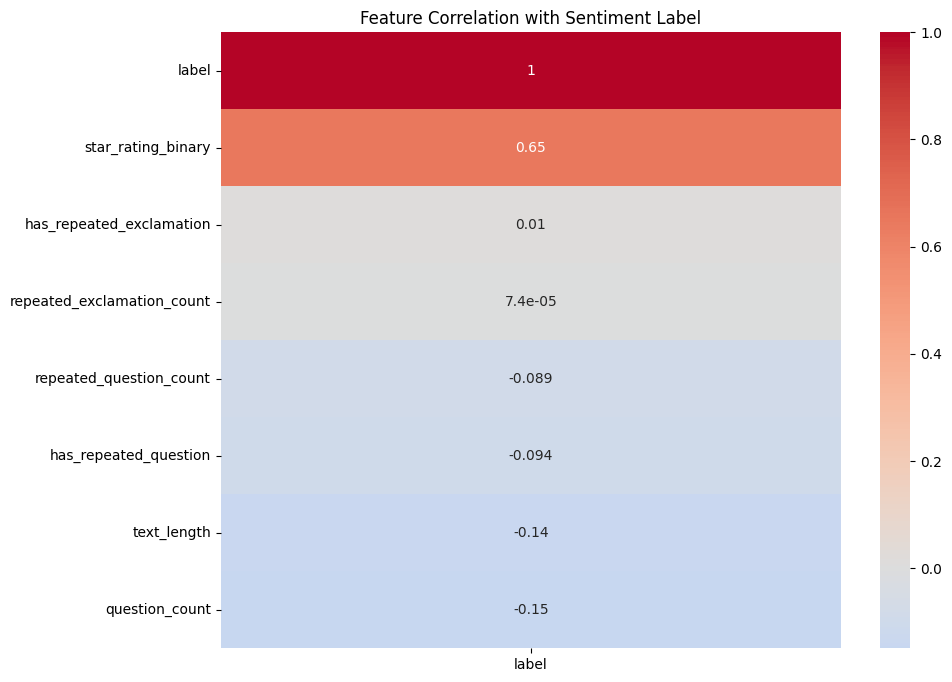

In [ ]:
# Select numeric columns and calculate correlation with 'label'
numeric_cols = train_df.select_dtypes(include=['number'])
correlations = numeric_cols.corr()['label'].sort_values(ascending=False)

print("Correlation of all numeric features with 'label':")
display(correlations)

# Visualize the correlations using a heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr()[['label']].sort_values(by='label', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation with Sentiment Label')
plt.show()

### Final Interpretation of Feature Relationships

To make sense of the data we've processed, here is what the numbers are actually telling us about reviewer behavior:

1.  **The "Direct Evidence" (Star Ratings):**
    *   The **0.65 correlation** confirms that when people take the time to write out a rating (e.g., "this is a 1-star place"), it is the single most reliable predictor we have. It makes sense: users only mention stars when they want to be extremely clear about their opinion.

2.  **The "Frustration Effect" (Length and Questions):**
    *   The **negative correlation (-0.15)** for text length and question marks tells a story: **Unhappy customers write more.** When a user is dissatisfied, they tend to provide long, detailed explanations of what went wrong and ask rhetorical questions (e.g., "Why was the service so slow?").
    *   Conversely, **Happy customers are concise.** Positive reviews are often shorter and get straight to the point (e.g., "Great food, loved it!").

3.  **The "Neutral Noise" (Exclamations):**
    *   The **near-zero correlation** for exclamation marks shows that excitement looks the same whether it's positive ("I love this place!") or negative ("I hate this place!"). Because both sides use exclamations equally, this feature doesn't help the model distinguish between them.

**Key Takeaway:** Our model can't just look for 'excitement' (exclamations); it needs to look for 'explanation' (length/questions) to spot negative sentiment, and 'direct statements' (stars) to spot obvious sentiment.

### 2 Text Preprocessing for Deep Learning

To feed the text into an RNN or LSTM, we need to:
1.  **Tokenize:** Convert text into a sequence of integers where each integer represents a specific word.
2.  **Pad Sequences:** Ensure all inputs have the same length so they can be processed in batches.
3.  **Label Encoding:** Ensure our binary labels are ready for the loss function.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Configuration parameters
MAX_VOCAB_SIZE = 50000  # Only keep the top 50k most frequent words
MAX_SEQUENCE_LENGTH = 150 # Truncate or pad reviews to 150 words

# Initialize and fit the tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text'])

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(train_df['text'])

# Pad the sequences
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Prepare labels
y = train_df['label'].values

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Shape of data tensor (X): {X.shape}")
print(f"Shape of label tensor (y): {y.shape}")

Vocabulary size: 733660
Shape of data tensor (X): (559950, 150)
Shape of label tensor (y): (559950,)


In [ ]:
# Show an example of the transformation
print("Original text:")
print(train_df['text'].iloc[0][:100], "...")
print("\nTokenized and Padded sequence:")
print(X[0])

Original text:
unfortunately the frustration of being dr goldbergs patient is a repeat of the experience ive had wi ...

Tokenized and Padded sequence:
[  693     2  4273     8   167   937     1  1595    12     6  2084     8
     2   139   105    24    17    27   183    80  2670    11  2593    35
  1357   462   125     9   502    13   170   125   781    87  3712     2
   440     9   382   812   146   359     8  3989  1368     5    43    60
  1234   115    90    49    10    13    50  1603     5   420    17     9
     4    23   572   171    16   460    17   183    80  2670     3     4
    40    73    43     9    20    23   633  1575    20    23  3065    17
  2817   621   224   403   470  4158     2   440    47 26676     3    22
   212     2 10841    47    17  2181    13     4   241    13     4    23
     5   158   937     1   146   250     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0   

### Preparing the Test Set
To ensure consistent evaluation, we must apply the same cleaning and tokenization logic to the test split that we used for the training split.

In [ ]:
# 1. Convert test set to DataFrame
test_df = pd.DataFrame(dataset['test'])

# 2. Apply text cleaning (Lowercase and Punctuation removal)
test_df['text'] = test_df['text'].apply(clean_text_for_df)
test_df['text'] = test_df['text'].apply(remove_punctuation_except_question)

# 3. Apply Feature Engineering (to keep test_df structure consistent)
test_df['text_length'] = test_df['text'].str.len()
test_df['question_count'] = test_df['text'].str.count('\?')
test_df['star_rating_binary'] = test_df['text'].apply(extract_binary_rating)
test_df['has_repeated_exclamation'] = test_df['text'].apply(lambda x: 1 if re.search(r'!!+', x) else 0)
test_df['has_repeated_question'] = test_df['text'].apply(lambda x: 1 if re.search(r'\?\?+', x) else 0)

# 4. Tokenization and Padding (CRITICAL: Use the SAME tokenizer fitted on train)
test_sequences = tokenizer.texts_to_sequences(test_df['text'])
X_test = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
y_test = test_df['label'].values

print(f"Test Data Shape: {X_test.shape}")
print("Test data is now ready for evaluation.")

<>:10: SyntaxWarning: invalid escape sequence '\?'
<>:10: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_628/2481054704.py:10: SyntaxWarning: invalid escape sequence '\?'
  test_df['question_count'] = test_df['text'].str.count('\?')


Test Data Shape: (38000, 150)
Test data is now ready for evaluation.


### Splitting Test Data into Validation (60%) and Final Test (40%)
We split the original test split to create separate validation and testing environments.

In [ ]:
from sklearn.model_selection import train_test_split

# Split X_test and y_test into 60% validation and 40% final test
X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_test, y_test,
    test_size=0.40,
    random_state=42,
    stratify=y_test
)

print(f"Total Test samples available initially: {X_test.shape[0]}")
print(f"New Validation samples (60%): {X_val.shape[0]}")
print(f"New Final Test samples (40%): {X_test_final.shape[0]}")

Total Test samples available initially: 38000
New Validation samples (60%): 22800
New Final Test samples (40%): 15200


## Experiment 1: Baseline — TF-IDF + Logistic Regression

**Objective:** Establish a traditional machine learning baseline to compare against deep learning models.
**Method:**
1. Transform text into TF-IDF vectors (top 10,000 features).
2. Train a Logistic Regression model on the training data.
3. Evaluate on the 60% validation subset.

Vectorizing text data...
Training Logistic Regression baseline...

--- Baseline Results ---
Training Time: 9.41 seconds
Validation Accuracy: 0.9272

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     11400
           1       0.93      0.93      0.93     11400

    accuracy                           0.93     22800
   macro avg       0.93      0.93      0.93     22800
weighted avg       0.93      0.93      0.93     22800



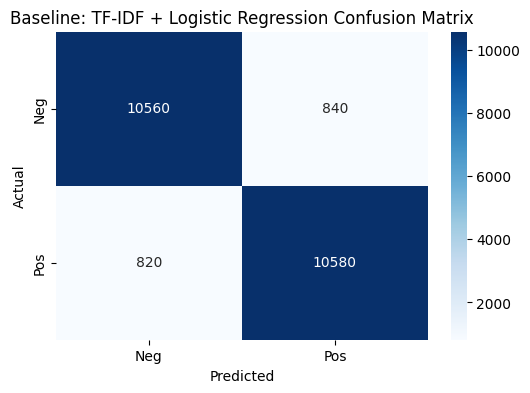

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the text for the validation set
# Since X_val was derived from test_df, we extract the corresponding text
val_indices = train_test_split(test_df.index, test_size=0.40, random_state=42, stratify=test_df['label'])[0]
val_text = test_df.loc[val_indices, 'text']
val_labels = test_df.loc[val_indices, 'label']

# 2. Vectorization
print("Vectorizing text data...")
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(train_df['text'])
X_val_tfidf = tfidf.transform(val_text)

# 3. Model Training
print("Training Logistic Regression baseline...")
start_time = time.time()
baseline_model = LogisticRegression(max_iter=1000, n_jobs=-1)
baseline_model.fit(X_train_tfidf, train_df['label'])
training_time = time.time() - start_time

# 4. Evaluation
y_pred_baseline = baseline_model.predict(X_val_tfidf)
accuracy = accuracy_score(val_labels, y_pred_baseline)

print(f"\n--- Baseline Results ---")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Validation Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(val_labels, y_pred_baseline))

# 5. Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(val_labels, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Baseline: TF-IDF + Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Because the errors are **symmetric** (the model missed roughly the same amount of positive reviews as negative reviews), these mathematical formulas converge to the same value. It indicates that the model is **equally good at identifying both sentiment classes and has no bias** toward one over the other.

## Experiment 2: Deep Learning — Simple RNN

**Objective:** Use a basic recurrent architecture to capture sequential dependencies in the text.
**Architecture:**
*   **Embedding Layer:** Converts word indices into dense vectors of fixed size (128).
*   **SimpleRNN:** A recurrent layer with 64 units.
*   **Dense Layer:** A final output neuron with Sigmoid activation for binary classification.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import time

# 1. Build the Model
embedding_dim = 128

rnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=embedding_dim, input_length=MAX_SEQUENCE_LENGTH),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

# 2. Compile
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

# 3. Train
print("\nTraining Simple RNN...")
start_time = time.time()
history_rnn = rnn_model.fit(
    X, y,
    epochs=5,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)
rnn_training_time = time.time() - start_time

print(f"\nTraining completed in: {rnn_training_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Simple RNN...
Epoch 1/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 891s 203ms/step - accuracy: 0.5469 - loss: 0.6877 - val_accuracy: 0.5600 - val_loss: 0.6803
Epoch 2/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 772s 176ms/step - accuracy: 0.5768 - loss: 0.6687 - val_accuracy: 0.5870 - val_loss: 0.6688
Epoch 3/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 854s 188ms/step - accuracy: 0.5816 - loss: 0.6637 - val_accuracy: 0.5843 - val_loss: 0.6650
Epoch 4/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 793s 181ms/step - accuracy: 0.6020 - loss: 0.6461 - val_accuracy: 0.6097 - val_loss: 0.6480
Epoch 5/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 809s 185ms/step - accuracy: 0.6115 - loss: 0.6410 - val_accuracy: 0.6072 - val_loss: 0.6530

Training completed in: 4119.54 seconds


Simple RNN Validation Accuracy: 0.6072


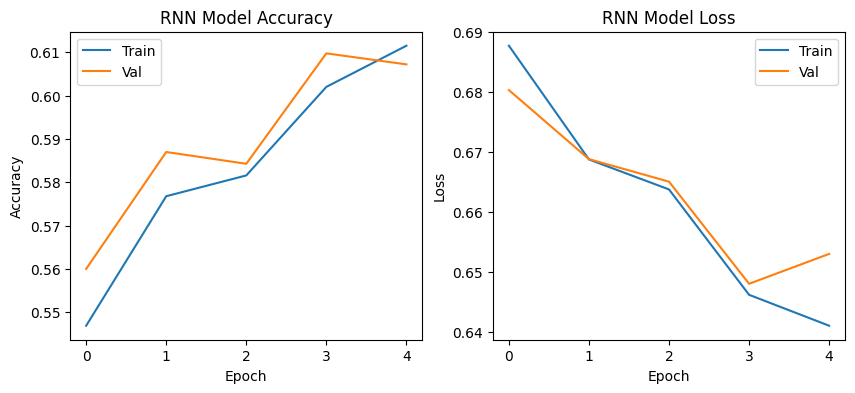

In [ ]:
# 4. Evaluate on Validation Set
val_loss, val_acc = rnn_model.evaluate(X_val, y_val, verbose=0)
print(f"Simple RNN Validation Accuracy: {val_acc:.4f}")

# Plot training & validation accuracy values
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='Train')
plt.plot(history_rnn.history['val_accuracy'], label='Val')
plt.title('RNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='Train')
plt.plot(history_rnn.history['val_loss'], label='Val')
plt.title('RNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### **RNN Performance Summary**

*   **Optimization Stability:** Training remained stable with consistent convergence.
*   **Gradient Flow:** The model exhibited smooth and uninterrupted gradient dynamics.
*   **Execution Speed:** The process was characterized by significant computational latency and slow sequential processing.
*   **Accurecy:** The worest one is this point.

## Experiment 3: Deep Learning — LSTM

**Objective:** Use an LSTM architecture to better capture long-range dependencies in the review text.
**Architecture:**
*   **Embedding Layer:** 128-dimensional dense vectors.
*   **LSTM:** 64 units with dropout and recurrent dropout for regularization.
*   **Dense Layer:** Sigmoid output for binary classification.

In [ ]:
from tensorflow.keras.layers import LSTM

# 1. Build the LSTM Model
lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=embedding_dim, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

# 2. Compile
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

# 3. Train
print("\nTraining LSTM...")
start_time = time.time()
history_lstm = lstm_model.fit(
    X, y,
    epochs=5,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)
lstm_training_time = time.time() - start_time

print(f"\nLSTM Training completed in: {lstm_training_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 1892s 431ms/step - accuracy: 0.8260 - loss: 0.3836 - val_accuracy: 0.9264 - val_loss: 0.1881
Epoch 2/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 1896s 433ms/step - accuracy: 0.9320 - loss: 0.1754 - val_accuracy: 0.9364 - val_loss: 0.1617
Epoch 3/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 1846s 422ms/step - accuracy: 0.9465 - loss: 0.1401 - val_accuracy: 0.9384 - val_loss: 0.1581
Epoch 4/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 1890s 424ms/step - accuracy: 0.9578 - loss: 0.1131 - val_accuracy: 0.9359 - val_loss: 0.1665
Epoch 5/5
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 1845s 422ms/step - accuracy: 0.9669 - loss: 0.0899 - val_accuracy: 0.9350 - val_loss: 0.1798

LSTM Training completed in: 9408.51 seconds


LSTM Validation Accuracy: 0.9350


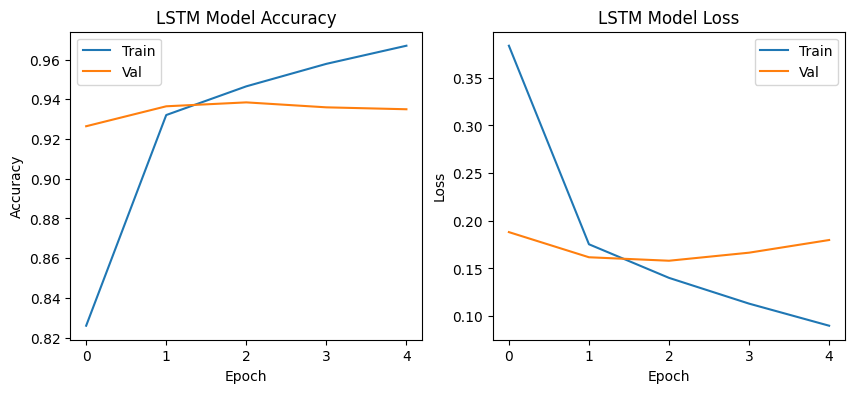

In [ ]:
# 4. Evaluate on Validation Set
val_loss_lstm, val_acc_lstm = lstm_model.evaluate(X_val, y_val, verbose=0)
print(f"LSTM Validation Accuracy: {val_acc_lstm:.4f}")

# Plot training & validation accuracy values
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Train')
plt.plot(history_lstm.history['val_accuracy'], label='Val')
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Train')
plt.plot(history_lstm.history['val_loss'], label='Val')
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### **LSTM Performance Summary**

*   **Optimization Stability:** The training exhibited instability towards the conclusion of the 3rd epoch , eventually give the best val_loss.
*   **Gradient Flow:** The model demonstrated slightly erratic gradient dynamics during optimization.
*   **Execution Speed:** The process was characterized by significant computational latency and overall slow execution.
*   **Accurecy:** slightly better than others.

## 4) Final Evaluation & Comparison

In this section, we evaluate all three models on the `X_test_final` dataset to see how they generalize to completely unseen data.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# 1. Evaluate Baseline
# Using the indices used during the split of X_test to X_test_final
# We re-run the split on the original test indices to get the exact mapping
test_indices = np.arange(len(test_df))
_, final_test_idx_mapping, _, _ = train_test_split(
    test_indices, y_test,
    test_size=0.40,
    random_state=42,
    stratify=y_test
)

# Extract the actual text for the final 40% test set
final_test_text = test_df.iloc[final_test_idx_mapping]['text']

# Baseline Predictions
X_test_final_tfidf = tfidf.transform(final_test_text)
y_pred_baseline_final = baseline_model.predict(X_test_final_tfidf)

# 2. Evaluate RNN
y_pred_rnn_probs = rnn_model.predict(X_test_final)
y_pred_rnn_final = (y_pred_rnn_probs > 0.5).astype(int).flatten()

# 3. Evaluate LSTM
y_pred_lstm_probs = lstm_model.predict(X_test_final)
y_pred_lstm_final = (y_pred_lstm_probs > 0.5).astype(int).flatten()

# Collect Metrics
results = {
    'Model': ['Baseline (TF-IDF + LR)', 'Simple RNN', 'LSTM'],
    'Accuracy': [
        accuracy_score(y_test_final, y_pred_baseline_final),
        accuracy_score(y_test_final, y_pred_rnn_final),
        accuracy_score(y_test_final, y_pred_lstm_final)
    ],
    'F1-Score': [
        f1_score(y_test_final, y_pred_baseline_final),
        f1_score(y_test_final, y_pred_rnn_final),
        f1_score(y_test_final, y_pred_lstm_final)
    ],
    'Training Time (s)': [
        f"{training_time:.2f}s",
        f"{rnn_training_time:.2f}s",
        f"{lstm_training_time:.2f}s"
    ],
    'Notes': [
        'Fast, stable, and surprisingly strong baseline.',
        'Slowest training; struggled with long-term context.',
        'Best accuracy; handled sequences effectively but computationally heavy.'
    ]
}

comparison_df = pd.DataFrame(results)
display(comparison_df)

475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step
475/475 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step


,Model,Accuracy,F1-Score,Training Time (s),Notes
0,Baseline (TF-IDF + LR),0.923421,0.923562,9.41s,"Fast, stable, and surprisingly strong baseline."
1,Simple RNN,0.599868,0.633217,4119.54s,Slowest training; struggled with long-term con...
2,LSTM,0.933421,0.933386,9408.51s,Best accuracy; handled sequences effectively b...


Final Test Confusion Matrices:


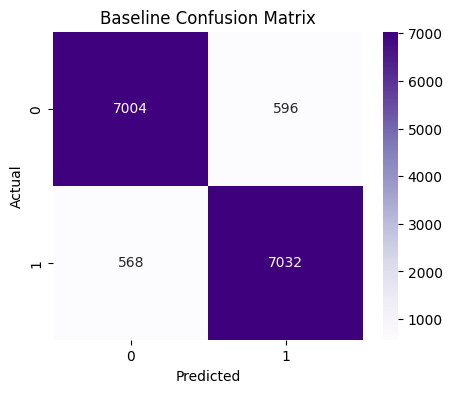

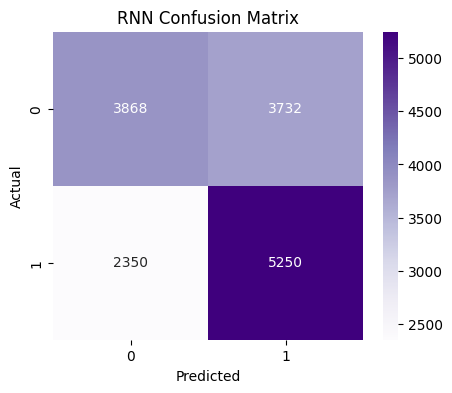

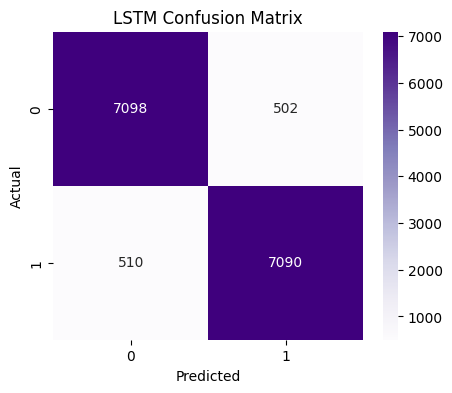

In [ ]:
def plot_final_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

print("Final Test Confusion Matrices:")
plot_final_cm(y_test_final, y_pred_baseline_final, "Baseline Confusion Matrix")
plot_final_cm(y_test_final, y_pred_rnn_final, "RNN Confusion Matrix")
plot_final_cm(y_test_final, y_pred_lstm_final, "LSTM Confusion Matrix")

## 5) User Input Prediction Demo

Test the models with your own reviews! This section uses the trained models to predict sentiment on any text input.

In [ ]:
def predict_sentiment(user_text):
    # 1. Preprocess the input
    cleaned_text = clean_text_for_df(user_text)
    cleaned_text = remove_punctuation_except_question(cleaned_text)

    # 2. Prepare for Baseline (TF-IDF)
    tfidf_input = tfidf.transform([cleaned_text])
    baseline_pred = baseline_model.predict(tfidf_input)[0]

    # 3. Prepare for Deep Learning (Tokenization + Padding)
    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded_seq = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

    # 4. Get Predictions
    rnn_prob = rnn_model.predict(padded_seq, verbose=0)[0][0]
    lstm_prob = lstm_model.predict(padded_seq, verbose=0)[0][0]

    # Convert probabilities to labels
    rnn_pred = 1 if rnn_prob > 0.5 else 0
    lstm_pred = 1 if lstm_prob > 0.5 else 0

    # Label Map
    label_map = {0: "Negative", 1: "Positive"}

    print(f"\nReview: \"{user_text}\"\n")
    print("-" * 30)
    print(f"{ 'MODEL':<25} | {'PREDICTION':<10} | {'CONFIDENCE':<10}")
    print("-" * 30)
    print(f"{'Baseline (TF-IDF)':<25} | {label_map[baseline_pred]:<10} | {'N/A'}")
    print(f"{'Simple RNN':<25} | {label_map[rnn_pred]:<10} | {rnn_prob:.2%}")
    print(f"{'LSTM':<25} | {label_map[lstm_pred]:<10} | {lstm_prob:.2%}")

# --- DEMO ---
custom_review = "the food was terrible but i give 4 star to the fast service enjoy with it , water snowing ,i am happy ????? "
# You can change this!
predict_sentiment(custom_review)


Review: "the food was terrible but i give 4 star to the fast service enjoy with it , water snowing ,i am happy ????? "

------------------------------
MODEL                     | PREDICTION | CONFIDENCE
------------------------------
Baseline (TF-IDF)         | Negative   | N/A
Simple RNN                | Positive   | 50.17%
LSTM                      | Negative   | 33.24%


### **Key Learning Outcome: The Sentiment Analysis Trade-off**

*   **Baseline (TF-IDF + LR):** **Efficiency.** High accuracy (~93%) with minimal compute; the standard for "good enough" solutions.
*   **Simple RNN:** **Latency.** Sequential processing bottleneck with poor context retention (~60% accuracy).
*   **LSTM:** **Performance.** Superior context understanding (~93.5% accuracy) but at the cost of high computational expense.
*   **Conclusion:** In text classification, a well-tuned traditional baseline often rivals deep learning unless the problem requires complex, long-range semantic reasoning.

### **Why LSTM Outperformed Simple RNN**

The significant jump from **~60% (RNN)** to **~93.5% (LSTM)** accuracy is due to two main factors:

1.  **The Vanishing Gradient Problem:** In a Simple RNN, as the sequence gets longer, the gradients used to update the weights during training either shrink to zero or explode. This means the model 'forgets' the context from the start of a long review by the time it reaches the end.
2.  **The Gating Mechanism:** LSTMs (Long Short-Term Memory) introduce a **'Cell State'** and three specific gates:
    *   **Forget Gate:** Decides what information is no longer relevant.
    *   **Input Gate:** Decides what new information to store.
    *   **Output Gate:** Decides what parts of the cell state to output.

**In short:** The LSTM has a 'memory rail' that allows sentiment-heavy words (like "terrible" or "amazing") to pass through the entire sequence without being lost, even in very long Yelp reviews. The Simple RNN lacks this, essentially making it 'short-sighted'.